# Ejercicio Formativo 2 Capítulo 2

## Importando librerías

In [166]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display #para mostrar más de un elemento por celda de Jupyter

## Misión 0: Aspectos Básicos

In [167]:
df = pd.read_csv("data_E2.csv")

In [168]:
display(df.head(10))

,Year,Month,Day,O3,PM2.5,Environmental_risk
0,2008,1,1,29.63,NaN,NaN
1,2008,1,2,21.46,NaN,NaN
2,2008,1,3,24.25,NaN,NaN
3,2008,1,4,29.04,NaN,NaN
4,2008,1,5,30.17,NaN,NaN
5,2008,1,6,29.50,NaN,NaN
6,2008,1,7,26.79,NaN,NaN
7,2008,1,8,25.29,NaN,NaN
8,2008,1,9,14.62,NaN,NaN
9,2008,1,10,18.17,NaN,NaN


Se obtiene sus métricas usando la función `describe()` de pandas.

In [169]:
df.describe()

,Year,Month,Day,O3,PM2.5
count,2984.000000,2984.000000,2984.000000,2878.000000,2725.000000
mean,2011.592493,6.419236,15.715818,16.313767,28.814594
std,2.357040,3.487660,8.804066,7.995680,17.479388
min,2008.000000,1.000000,1.000000,1.000000,5.000000
25%,2010.000000,3.000000,8.000000,9.392500,16.170000
50%,2012.000000,6.000000,16.000000,16.960000,23.210000
75%,2014.000000,9.000000,23.000000,22.357500,37.210000
max,2016.000000,12.000000,31.000000,56.300000,126.200000


Para los valores no númericos se ve la frecuencia de los valores usando la función `value_counts()` de pandas.

In [170]:
environmental_risk = df["Environmental_risk"]
display(environmental_risk)

0         NaN
1         NaN
2         NaN
3         NaN
4         NaN
        ...  
2979     Bajo
2980     Bajo
2981     Bajo
2982    medio
2983    medio
Name: Environmental_risk, Length: 2984, dtype: object

In [171]:
environmental_risk.value_counts()

Environmental_risk
medio      1605
Bajo        750
nulo        134
Alto        106
extremo      61
Name: count, dtype: int64

## Misión 1: Limpieza y depuración

### Valores extremos

#### Columna O3

En primer lugar se usara un gráfico de caja y bigote para identificar los valores extremos de la columna O3.

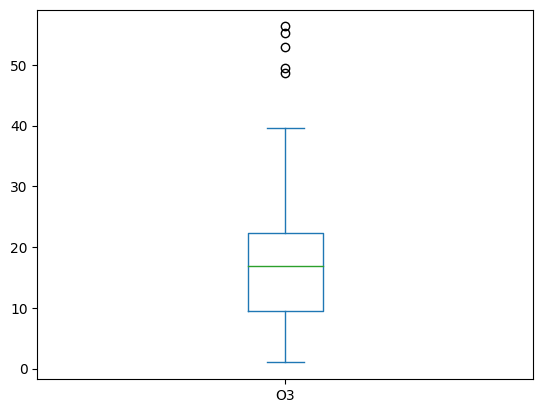

In [172]:
df['O3'].plot.box()
plt.show()

Se puede ver que los valores extremos son los que estan por sobre el bigote superior.

##### Corrigiendo valores extremos

In [173]:
df_log = df.copy()

Para corregir los valores extremos se mantendrán solo aquellos que esten por debajo del bigote superior de la caja, el cual es igual a 40. Para lograr esto se usa la función `loc` de pandas. La cual permite seleccionar solo aquellos valores que cumplan con la condición.

In [174]:
df = df.loc[df["O3"] <= 40]

Ahora se revisa nuevamente el diagrama de caja y bigote para verificar que los valores extremos han sido eliminados.

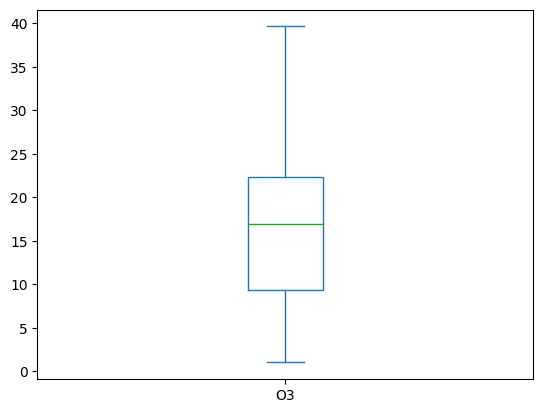

In [175]:
df['O3'].plot.box()
plt.show()

En clase también se vió que una manera de reducir el efecto de los valores extremos es aplicar una transformación logarítmica a los datos. Para esto se usa la función `np.log` de numpy.

In [176]:
df_log['O3'] = np.log(df_log['O3'])

<Axes: >

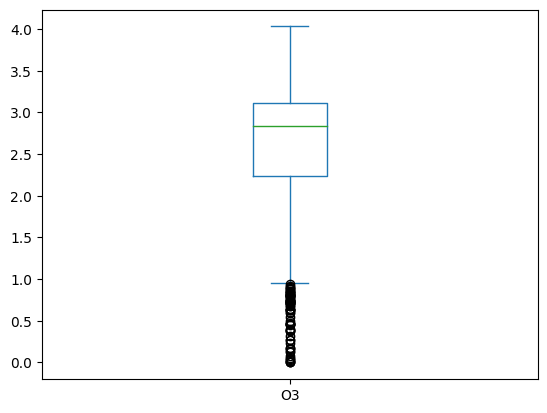

In [177]:
df_log['O3'].plot.box()

Como se puede ver en el gráfico de caja y bigote, usando este método los valores extremos pasaron de estar por sobre el bigote superior a estar por debajo del bigote inferior e incluso se puede ver que hay más valores extremos. Por lo tanto esta manera no es efectiva para corregir los valores extremos. Debido a esto se procederá a eliminar los valores extremos como se vio en el primer método.

#### Columna PM2.5

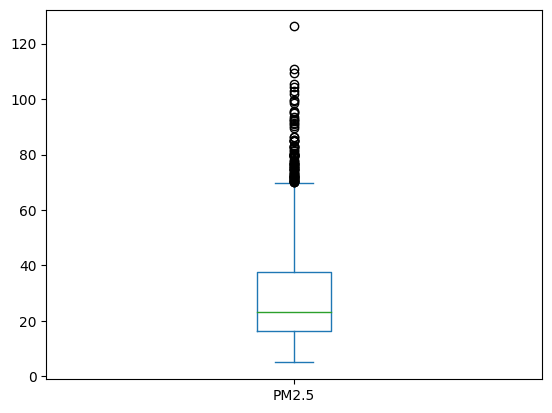

In [178]:
df['PM2.5'].plot.box()
plt.show()

Se puede ver que los valores extremos son los que estan por sobre el bigote superior al igual que en la columna O3. Sin embargo, a diferencia de la columna O3, en la columna PM2.5 se puede ver una gran presencia de valores extremos por ello si se decidiera eliminar los valores extremos se perdería una gran cantidad de datos, por ende en este caso se optará por tratar de reducir el efecto de los valores extremos aplicando una transformación logarítmica a los datos.

##### Corrigiendo valores extremos

In [179]:
df['PM2.5'] = np.log(df['PM2.5'])

Ahora se revisa nuevamente el diagrama de caja y bigote para ver el estado de los valores extremos.

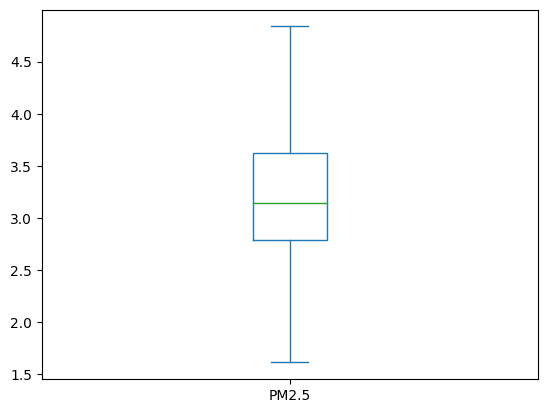

In [180]:
df['PM2.5'].plot.box()
plt.show()

### Valores Nulos

Se hace uso de la línea de código presentada en el material de clase para ver la cantidad de valores nulos.

In [181]:
df.apply(lambda x: sum(x.isnull()),axis=0) 

Year                    0
Month                   0
Day                     0
O3                      0
PM2.5                 222
Environmental_risk    222
dtype: int64

Se crean copias de los dataframes para no modificar el original y ejecutar las correcciones en las copias. El dataframe `df_mean` tendrá el método en el cual los valores nulos se reemplazan por la media mientras que `df_delete` tendrá el método en el cual se eliminan los valores nulos.

In [182]:
df_mean = df.copy()
df_delete = df.copy()

Para el primer método que nos fue solicitado se hace uso de la función`fillna()` de pandas para rellenar los valores nulos con el promedio de la columna.

In [183]:
df_mean['O3'] = df_mean['O3'].fillna(df['O3'].mean())
df_mean['PM2.5'] = df_mean['PM2.5'].fillna(df['PM2.5'].mean())


Para el segundo método se hace uso de la función `dropna()` de pandas para eliminar las filas que contengan valores nulos, especificando las columnas que se revisarán usando el parámetro `subset`.

In [184]:
df_delete = df_delete.dropna(subset=['O3', 'PM2.5'])

## Misión 2

### Tabla para Dataframe que se reemplazo valores nulos por la media

In [185]:
mean_O3 = df_mean['O3'].mean()
std_O3 = df_mean['O3'].std()
max_O3 = df_mean['O3'].max()
min_O3 = df_mean['O3'].min()
kurtosis_O3 = df_mean['O3'].kurtosis()

mean_PM25 = df_mean['PM2.5'].mean()
std_PM25 = df_mean['PM2.5'].std()
max_PM25 = df_mean['PM2.5'].max()
min_PM25 = df_mean['PM2.5'].min()
kurtosis_PM25 = df_mean['PM2.5'].kurtosis()

corr_O3_PM25 = df_mean['O3'].corr(df_mean['PM2.5'])

tabla_ordenda = pd.DataFrame({
    'Estadístico': ['Media', 'Desviación estándar', 'Máximo', 'Mínimo', 'Curtosis', 'Correlación O3-PM2.5'],
    'O3': [mean_O3, std_O3, max_O3, min_O3, kurtosis_O3, corr_O3_PM25],
    'PM2.5': [mean_PM25, std_PM25, max_PM25, min_PM25, kurtosis_PM25, '']
})

display(tabla_ordenda)
     

,Estadístico,O3,PM2.5
0,Media,16.250821,3.201269
1,Desviación estándar,7.857782,0.548864
2,Máximo,39.650000,4.837868
3,Mínimo,1.000000,1.609438
4,Curtosis,-0.944356,-0.328626
5,Correlación O3-PM2.5,-0.432477,


### Tabla para Dataframe en la que se eliminaron las filas con valores nulos

In [186]:
mean_O3 = df_delete['O3'].mean()
std_O3 = df_delete['O3'].std()
max_O3 = df_delete['O3'].max()
min_O3 = df_delete['O3'].min()
kurtosis_O3 = df_delete['O3'].kurtosis()

mean_PM25 = df_delete['PM2.5'].mean()
std_PM25 = df_delete['PM2.5'].std()
max_PM25 = df_delete['PM2.5'].max()
min_PM25 = df_delete['PM2.5'].min()
kurtosis_PM25 = df_delete['PM2.5'].kurtosis()

corr_O3_PM25 = df_delete['O3'].corr(df_delete['PM2.5'])

tabla_ordenda = pd.DataFrame({
    'Estadístico': ['Media', 'Desviación estándar', 'Máximo', 'Mínimo', 'Curtosis', 'Correlación O3-PM2.5'],
    'O3': [mean_O3, std_O3, max_O3, min_O3, kurtosis_O3, corr_O3_PM25],
    'PM2.5': [mean_PM25, std_PM25, max_PM25, min_PM25, kurtosis_PM25, '']
})

display(tabla_ordenda)

,Estadístico,O3,PM2.5
0,Media,15.892422,3.201269
1,Desviación estándar,7.890672,0.571391
2,Máximo,39.650000,4.837868
3,Mínimo,1.000000,1.609438
4,Curtosis,-0.944448,-0.535191
5,Correlación O3-PM2.5,-0.448351,


## Misión 3: Visualización

### Dataframe que se reemplazo valores nulos por la media

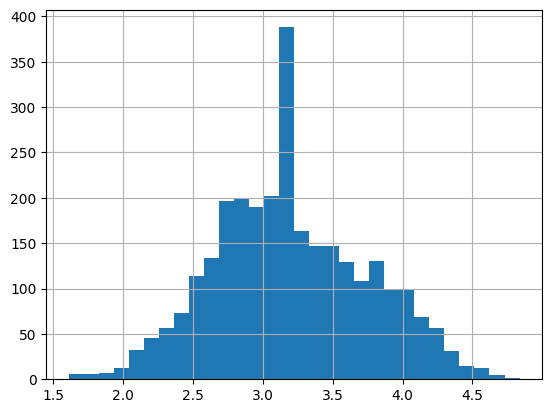

In [187]:
df_mean['PM2.5'].hist(bins=30)
plt.show()

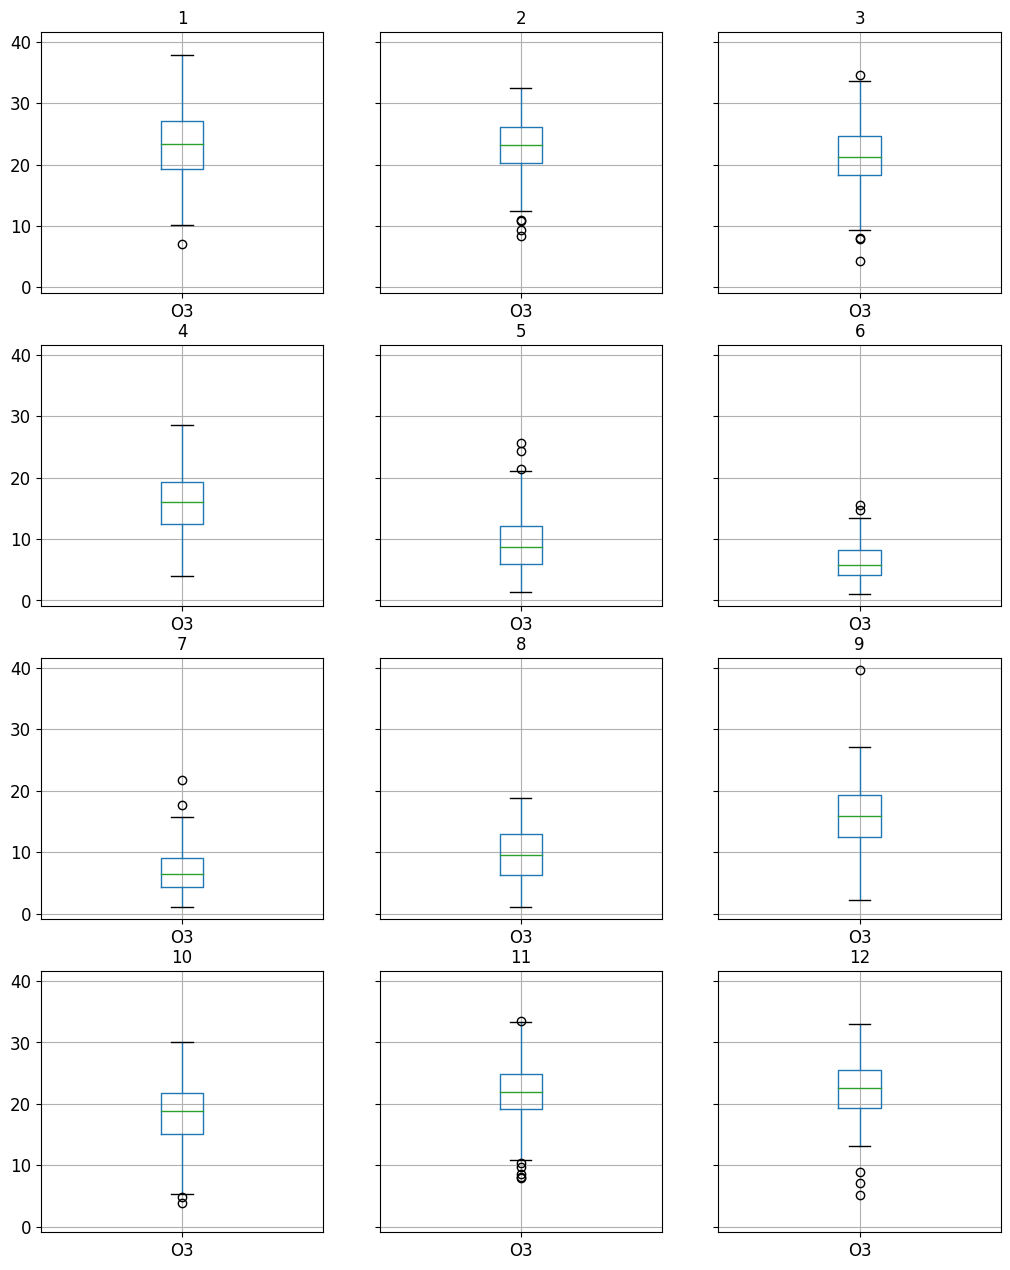

In [188]:
df_mean.groupby('Month').boxplot(column='O3', fontsize=12, figsize=(12, 16))
plt.show()

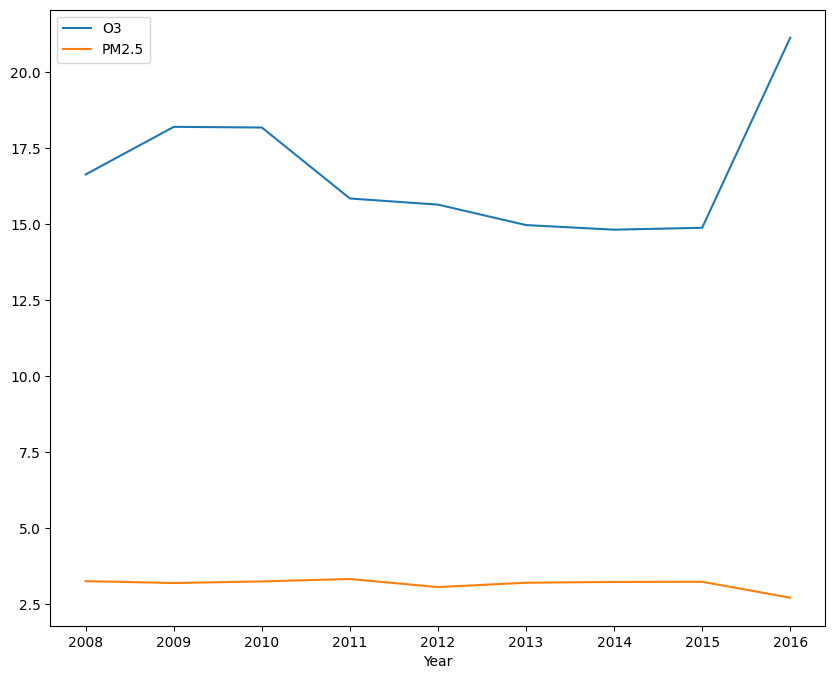

In [189]:
df_mean.groupby("Year")[["O3", "PM2.5"]].mean().plot.line(figsize=(10, 8))
plt.show()

### Dataframe que se corrigió eliminando filas con valores nulos

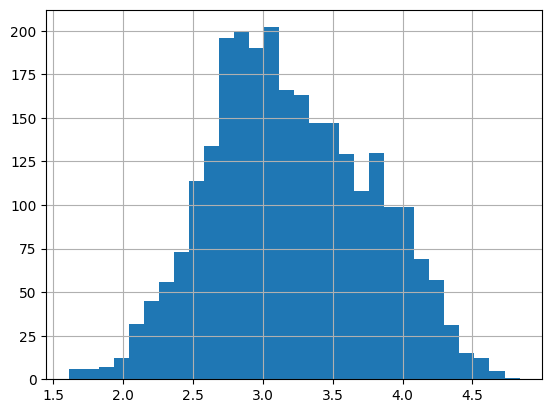

In [190]:
df_delete['PM2.5'].hist(bins=30)
plt.show()

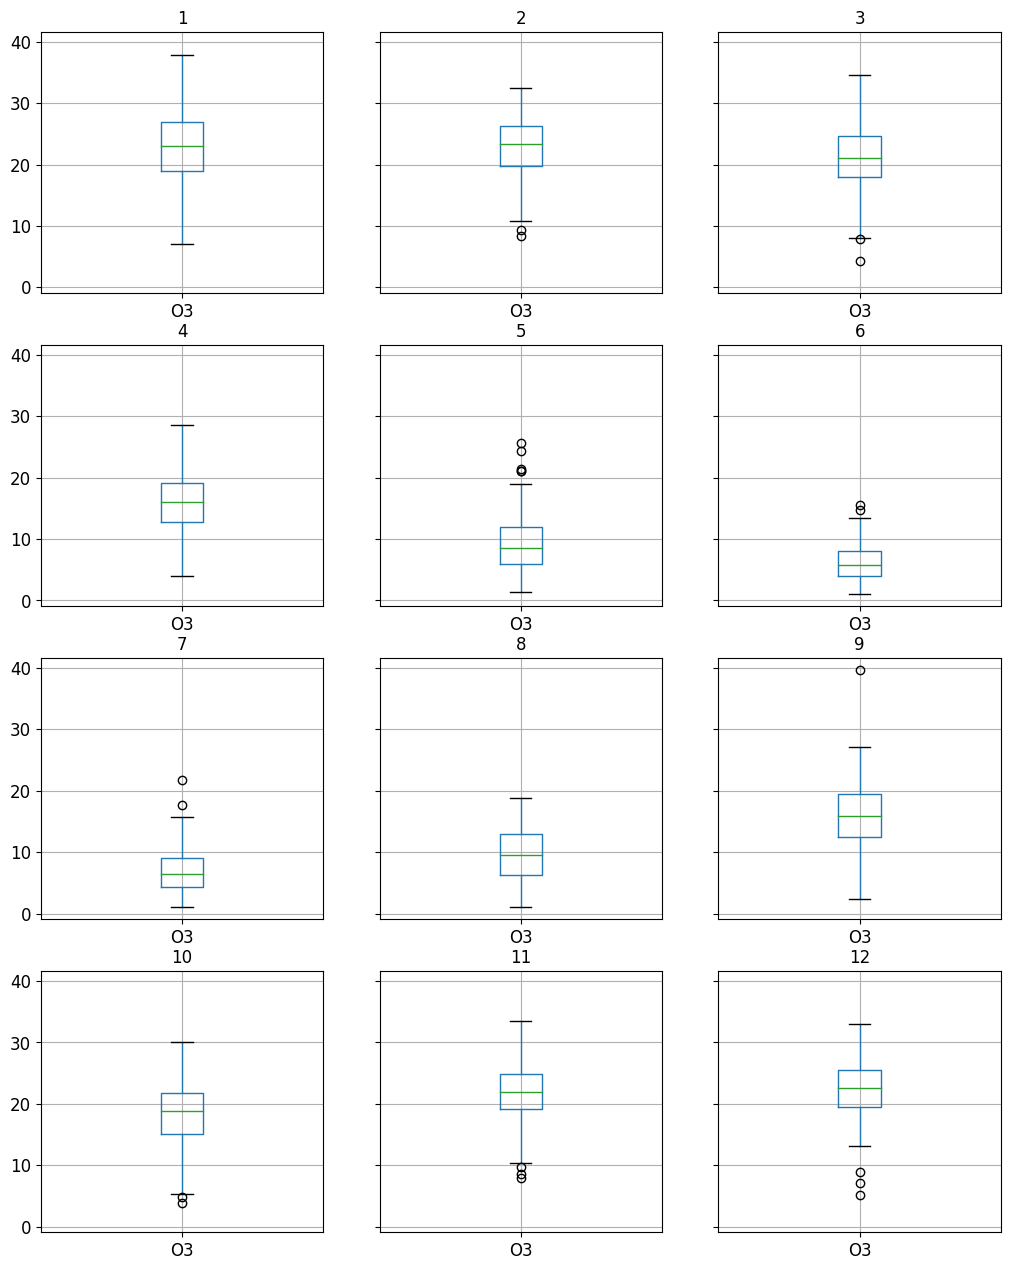

In [191]:
df_delete.groupby('Month').boxplot(column='O3', fontsize=12, figsize=(12, 16))
plt.show()

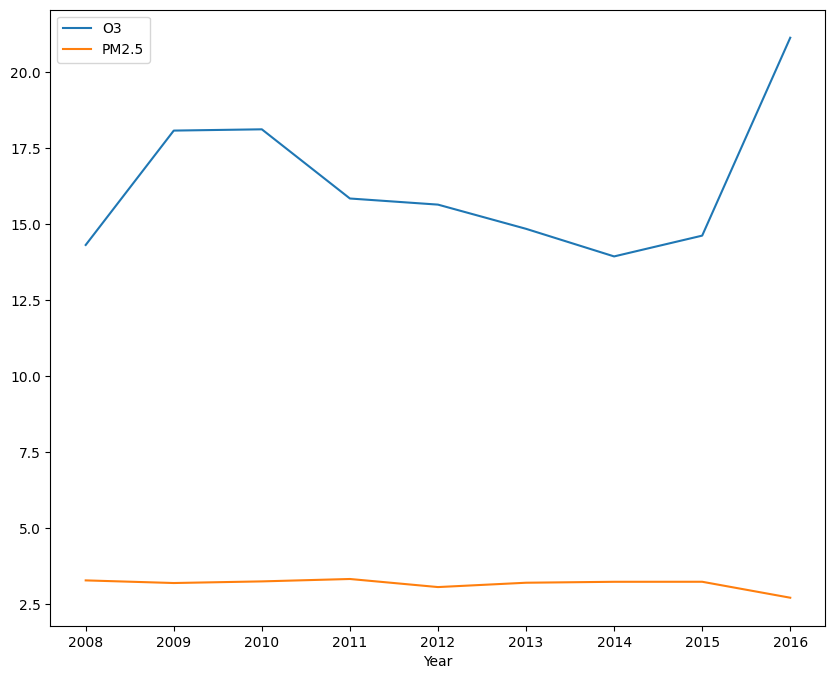

In [192]:
df_delete.groupby("Year")[["O3", "PM2.5"]].mean().plot.line(figsize=(10, 8))
plt.show()

# Misión 4: Categorización

Para esta misión se creo una función llamada `determinar_categoria`, la cual recibe como parámetros la fila que se estará revisando y métricas de la columna que se estará revisando. La función determina la categoría de la fila según las métricas de la columna. Se utilizarón las métricas de media y desviación estandard para determinar la categoría de la fila. Esto debido a que la primera indica el valor promedio de la columna y la segunda indica la dispersión de los datos. Por ende si se dispersaba mucho por sobre la media se consideraba una categoría alta, si se dispersaba mucho por debajo de la media se consideraba una categoría baja y si se dispersaba poco se consideraba una categoría media.

In [193]:
def determinar_categoria(fila, media_O3, std_O3, media_PM25, std_PM25):
    if pd.isnull(fila['Environmental_risk']):
        if fila['O3'] > media_O3:
            if fila['O3'] > media_O3 + 2 * std_O3:
                return 'extremo'
            else:
                if fila['PM2.5'] > media_PM25:
                    if fila['PM2.5'] > media_PM25 + 2 * std_PM25:
                        return 'extremo'
                    else:
                        return 'Alto'
                else:
                    return 'medio'
        else:
            return 'Bajo'
    else:
        return fila['Environmental_risk']

### Dataframe que se reemplazo valores nulos por la media

In [194]:
df_mean.apply(lambda x: sum(x.isnull()),axis=0) 

Year                    0
Month                   0
Day                     0
O3                      0
PM2.5                   0
Environmental_risk    222
dtype: int64

In [195]:
df_mean['Environmental_risk'].value_counts()

Environmental_risk
medio      1602
Bajo        750
nulo        134
Alto        105
extremo      60
Name: count, dtype: int64

Para aplicar esta función se hace uso de la función `apply` de pandas, la cual permite aplicar una función a cada fila de un dataframe, esto señalando que el parámetro `axis` es igual a 1.

In [196]:
media_O3 = df_mean['O3'].mean()
std_O3 = df_mean['O3'].std()
media_PM25 = df_mean['PM2.5'].mean()
std_PM25 = df_mean['PM2.5'].std()
df_mean['Environmental_risk'] = df_mean.apply(determinar_categoria, args=(media_O3, std_O3, media_PM25, std_PM25), axis=1)

In [197]:
df_mean.apply(lambda x: sum(x.isnull()),axis=0) 

Year                  0
Month                 0
Day                   0
O3                    0
PM2.5                 0
Environmental_risk    0
dtype: int64

In [198]:
df_mean['Environmental_risk'].value_counts()

Environmental_risk
medio      1602
Bajo        793
Alto        282
nulo        134
extremo      62
Name: count, dtype: int64

### Dataframe que se corrigió eliminando filas con valores nulos

In [199]:
df_delete.apply(lambda x: sum(x.isnull()),axis=0) 

Year                  0
Month                 0
Day                   0
O3                    0
PM2.5                 0
Environmental_risk    0
dtype: int64

In [200]:
df_delete['Environmental_risk'].value_counts()

Environmental_risk
medio      1602
Bajo        750
nulo        134
Alto        105
extremo      60
Name: count, dtype: int64

In [201]:
media_O3 = df_delete['O3'].mean()
std_O3 = df_delete['O3'].std()
media_PM25 = df_delete['PM2.5'].mean()
std_PM25 = df_delete['PM2.5'].std()
df_delete['Environmental_risk'] = df_delete.apply(determinar_categoria, args=(media_O3, std_O3, media_PM25, std_PM25), axis=1)

In [202]:
df_delete.apply(lambda x: sum(x.isnull()),axis=0) 

Year                  0
Month                 0
Day                   0
O3                    0
PM2.5                 0
Environmental_risk    0
dtype: int64

In [203]:
df_delete['Environmental_risk'].value_counts()

Environmental_risk
medio      1602
Bajo        750
nulo        134
Alto        105
extremo      60
Name: count, dtype: int64

# Misión 5: Análisis temporal avanzado

Se asignará de enero a marzo como verano, abril a junio como otoño, julio a septiembre como invierno y octubre a diciembre como primavera. Usaremos el df_delete

In [204]:
def asignar_estacion(mes):
    if mes in [1, 2, 12]:
        return 'Verano'
    elif mes in [4, 5, 3]:
        return 'Otoño'
    elif mes in [7, 8, 6]:
        return 'Invierno'
    else:
        return 'Primavera'

# Apply the function to create a new 'color' column
df_delete['Estacion'] = df_delete['Month'].apply(asignar_estacion)

print(df_delete)

      Year  Month  Day     O3     PM2.5 Environmental_risk Estacion
127   2008      5    7   8.46  3.882182              medio    Otoño
128   2008      5    8  12.96  4.035479              medio    Otoño
129   2008      5    9  12.00  3.988984              medio    Otoño
130   2008      5   10  15.33  4.239887              medio    Otoño
131   2008      5   11  18.12  4.511738              medio    Otoño
...    ...    ...  ...    ...       ...                ...      ...
2979  2016      2   27  22.93  2.840247               Bajo   Verano
2980  2016      2   28  26.70  2.729812               Bajo   Verano
2981  2016      2   29  24.62  2.830858               Bajo   Verano
2982  2016      3    1  28.86  3.486457              medio    Otoño
2983  2016      3    2  28.78  3.330775              medio    Otoño

[2651 rows x 7 columns]


In [205]:
df_delete.groupby(['Estacion', 'Year'])['O3'].mean()

Estacion   Year
Invierno   2008     7.083370
           2009    10.219111
           2010    10.490341
           2011     7.160217
           2012     8.026742
           2013     8.009239
           2014     4.926941
           2015     4.664713
Otoño      2008     8.758400
           2009    16.968804
           2010    18.440118
           2011    14.494891
           2012    15.649157
           2013    12.877802
           2014    14.799667
           2015    14.296118
           2016    28.820000
Primavera  2008    18.942747
           2009    19.633077
           2010    19.226163
           2011    20.496889
           2012    18.593333
           2013    19.356739
           2014    13.961250
           2015    16.368267
Verano     2008    26.594516
           2009    25.981905
           2010    24.315227
           2011    21.661512
           2012    20.223187
           2013    21.482778
           2014    23.065733
           2015    23.253182
           2016    20.82557

In [206]:
df_delete.groupby(['Estacion', 'Year'])['PM2.5'].mean()

Estacion   Year
Invierno   2008    3.638266
           2009    3.618276
           2010    3.672422
           2011    3.617622
           2012    3.506505
           2013    3.626986
           2014    3.756710
           2015    3.888298
Otoño      2008    3.712807
           2009    3.364263
           2010    3.445924
           2011    3.373278
           2012    3.299320
           2013    3.261004
           2014    3.231486
           2015    3.447526
           2016    3.408616
Primavera  2008    2.914193
           2009    2.807423
           2010    2.906933
           2011    3.162249
           2012    2.663795
           2013    3.021110
           2014    2.936363
           2015    2.786562
Verano     2008    2.876000
           2009    2.933751
           2010    2.928778
           2011    3.099723
           2012    2.752451
           2013    2.774564
           2014    2.770496
           2015    2.734189
           2016    2.674304
Name: PM2.5, dtype: float64

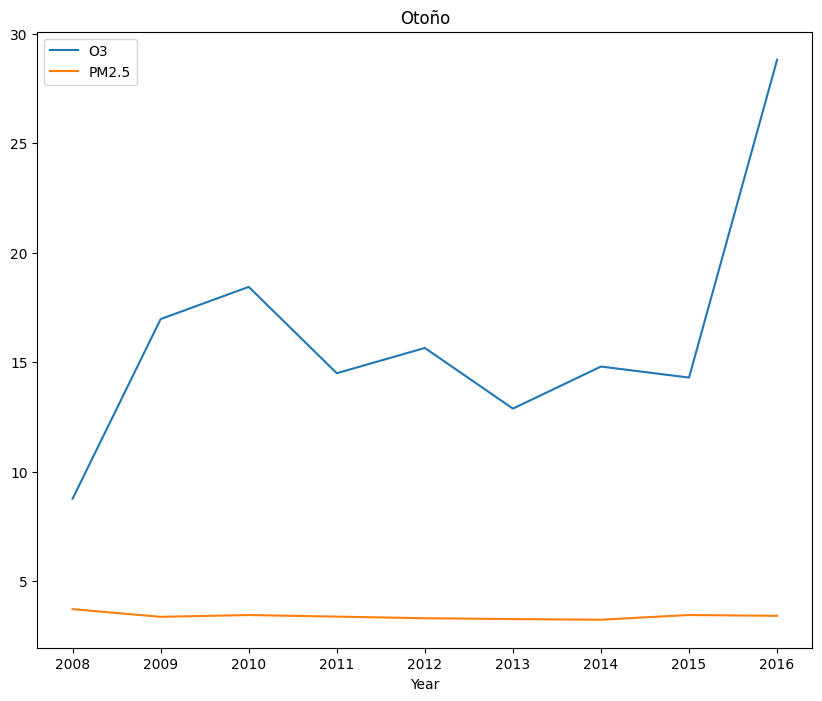

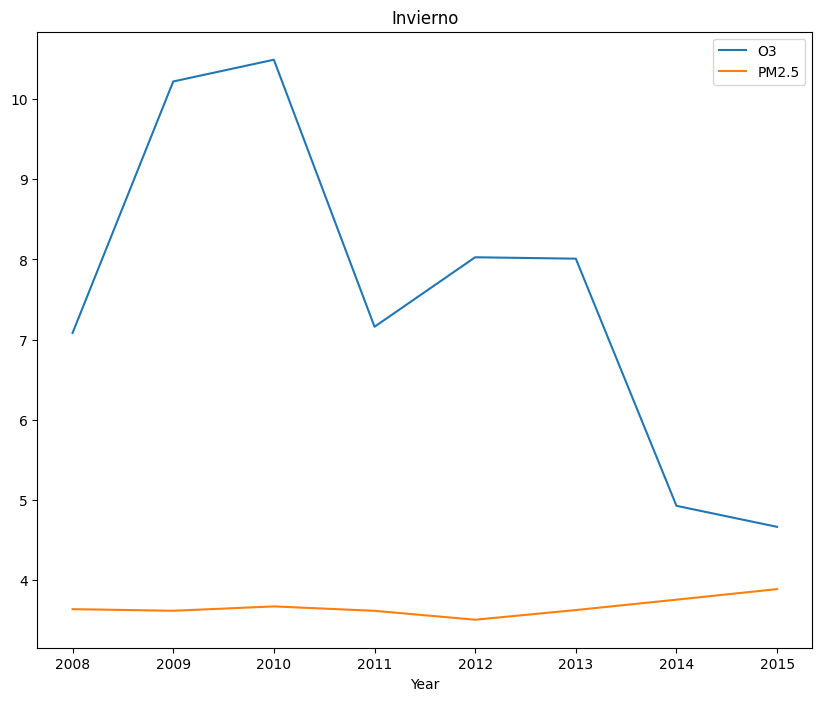

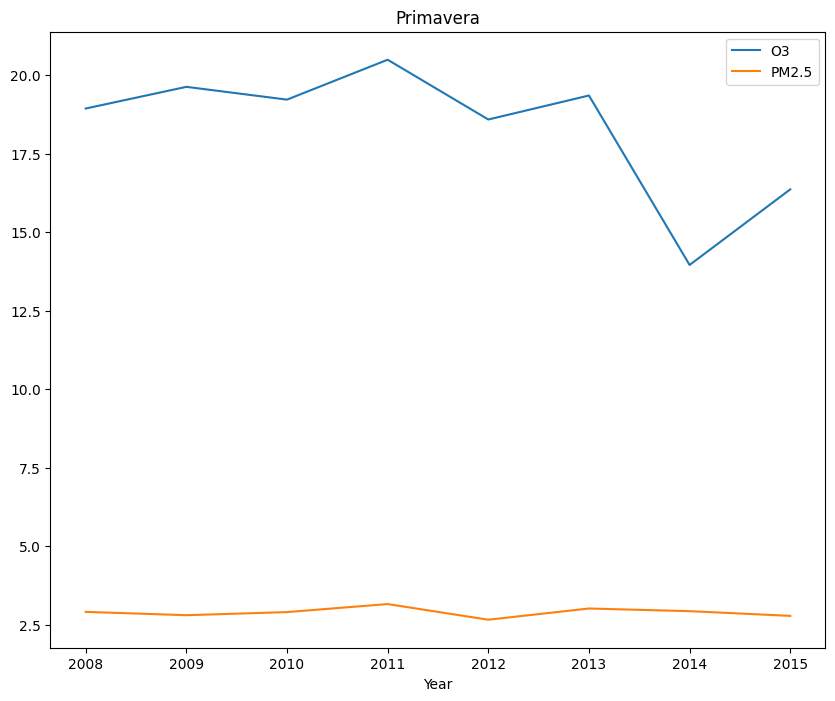

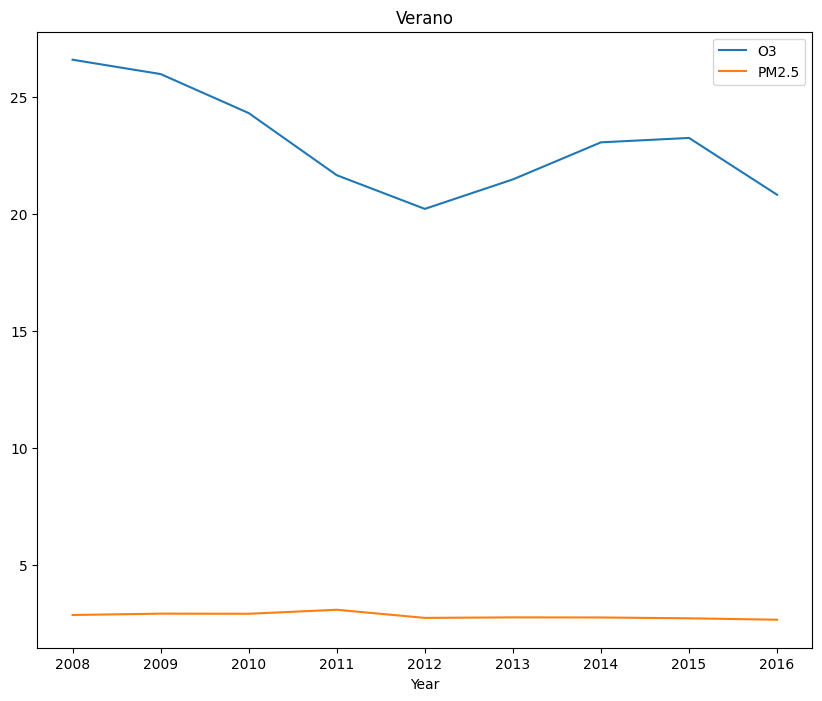

In [207]:
for value in pd.unique(df_delete['Estacion'].values):
    sub_df = df_delete[df_delete['Estacion'] == value]
    sub_df.groupby("Year")[["O3", "PM2.5"]].mean().plot.line(figsize=(10, 8))
    plt.title(value)
    plt.show()

# Misión 6: Detección de Anomalías

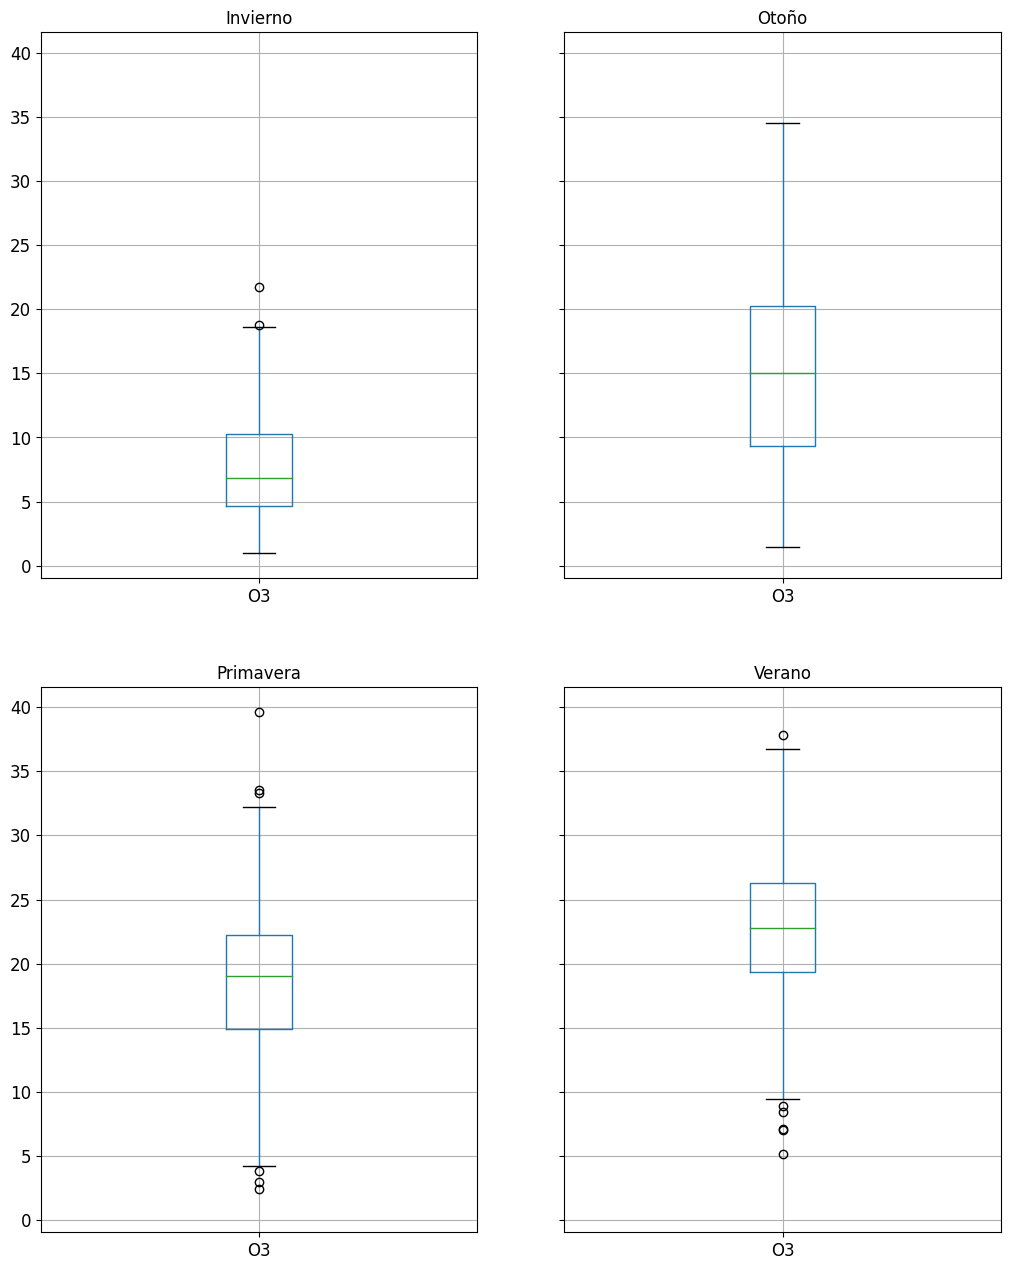

In [208]:
df_delete.groupby('Estacion').boxplot(column='O3', fontsize=12, figsize=(12, 16))
plt.show()

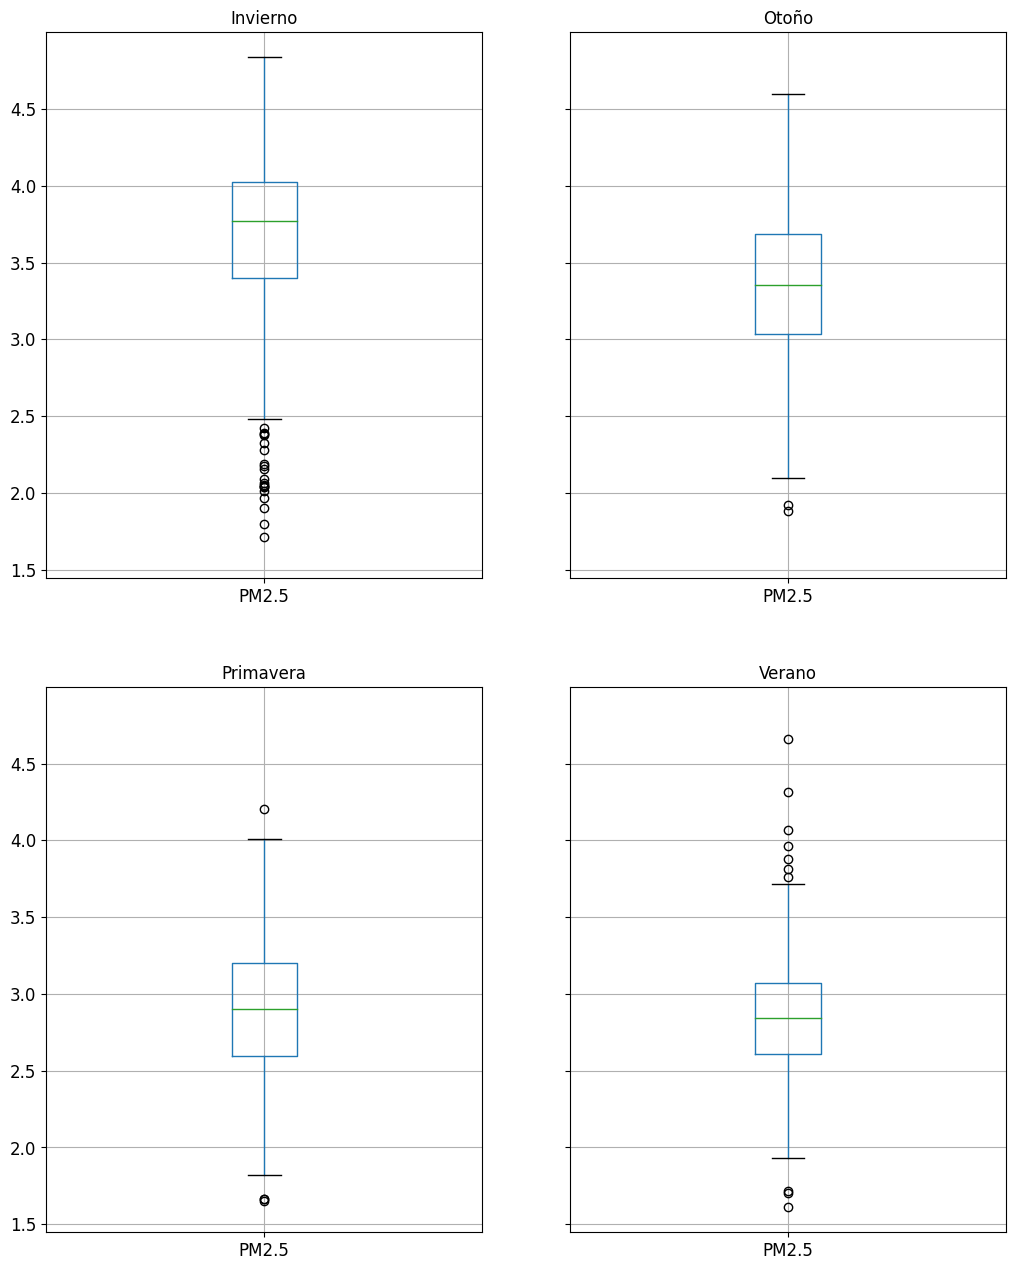

In [209]:
df_delete.groupby('Estacion').boxplot(column='PM2.5', fontsize=12, figsize=(12, 16))
plt.show()

Ahora creamos un nuevo df con los datos atípicos encontrados ahora.

In [210]:
df_atipicos = df_delete[((df_delete['O3'] > 19) & (df_delete['Estacion'] == 'Invierno')) |
                         (((df_delete['O3'] > 36.5) | (df_delete['O3'] < 9.5)) & (df_delete['Estacion'] == 'Verano')) |
                         (((df_delete['O3'] > 32.5) | (df_delete['O3'] < 4.5)) & (df_delete['Estacion'] == 'Primavera')) |
                         ((df_delete['PM2.5'] < 2.5) & (df_delete['Estacion'] == 'Invierno')) |
                         ((df_delete['PM2.5'] < 2.05) & (df_delete['Estacion'] == 'Otoño')) |
                         (((df_delete['PM2.5'] > 4) | (df_delete['PM2.5'] < 1.8)) & (df_delete['Estacion'] == 'Primavera')) |
                         (((df_delete['PM2.5'] < 1.95)| (df_delete['PM2.5'] > 3.7)) & (df_delete['Estacion'] == 'Verano'))]

In [211]:
conteo = df_atipicos.groupby(['Year', 'Month']).size()

print(conteo)

Year  Month
2008  7        1
      8        4
      11       2
2009  6        1
      7        1
      8        1
      9        1
2010  1        2
      6        1
      7        1
      11       1
      12       1
2011  1        1
      2        3
      3        1
      6        1
      7        2
      10       1
      12       1
2012  1        1
      2        2
      6        1
      7        2
      8        2
      9        1
      10       1
      12       3
2013  2        1
      5        1
      8        1
2014  1        3
      9        2
      12       1
2015  1        1
      7        2
      8        1
      9        2
      11       2
2016  1        1
dtype: int64


Se puede observar que en general los datos atípicos están muy distribuidos entre meses y años, eso sí, hay unos meses donde hubieron hartos días con días atípicos, como Agosto del 2008, febrero del 2011, diciembre del 2012 y enero del 2014.

# Misión 7: Transformación y enriquecimiento de los datos

In [212]:
df = df_delete.copy()

In [213]:
df['ratio'] = df['O3'] / df['PM2.5']
df['Fecha'] = pd.to_datetime(df[['Year', 'Month', 'Day']])

print(df)

      Year  Month  Day     O3     PM2.5 Environmental_risk Estacion     ratio  \
127   2008      5    7   8.46  3.882182              medio    Otoño  2.179187   
128   2008      5    8  12.96  4.035479              medio    Otoño  3.211515   
129   2008      5    9  12.00  3.988984              medio    Otoño  3.008285   
130   2008      5   10  15.33  4.239887              medio    Otoño  3.615663   
131   2008      5   11  18.12  4.511738              medio    Otoño  4.016190   
...    ...    ...  ...    ...       ...                ...      ...       ...   
2979  2016      2   27  22.93  2.840247               Bajo   Verano  8.073240   
2980  2016      2   28  26.70  2.729812               Bajo   Verano  9.780894   
2981  2016      2   29  24.62  2.830858               Bajo   Verano  8.697011   
2982  2016      3    1  28.86  3.486457              medio    Otoño  8.277744   
2983  2016      3    2  28.78  3.330775              medio    Otoño  8.640632   

          Fecha  
127  2008

In [214]:
df['Día de la Semana'] = df['Fecha'].dt.dayofweek

# Clasificar como "Fin de Semana" o "Día Laboral"
df['Tipo de Día'] = df['Día de la Semana'].apply(lambda x: 'Fin de Semana' if x >= 5 else 'Día Laboral')


In [215]:
df.head(10)

,Year,Month,Day,O3,PM2.5,Environmental_risk,Estacion,ratio,Fecha,Día de la Semana,Tipo de Día
127,2008,5,7,8.46,3.882182,medio,Otoño,2.179187,2008-05-07,2,Día Laboral
128,2008,5,8,12.96,4.035479,medio,Otoño,3.211515,2008-05-08,3,Día Laboral
129,2008,5,9,12.00,3.988984,medio,Otoño,3.008285,2008-05-09,4,Día Laboral
130,2008,5,10,15.33,4.239887,medio,Otoño,3.615663,2008-05-10,5,Fin de Semana
131,2008,5,11,18.12,4.511738,medio,Otoño,4.016190,2008-05-11,6,Fin de Semana
132,2008,5,12,12.88,4.008968,medio,Otoño,3.212797,2008-05-12,0,Día Laboral
133,2008,5,13,12.92,4.080753,medio,Otoño,3.166083,2008-05-13,1,Día Laboral
134,2008,5,14,13.92,3.759804,medio,Otoño,3.702321,2008-05-14,2,Día Laboral
135,2008,5,15,12.08,4.402564,medio,Otoño,2.743855,2008-05-15,3,Día Laboral
136,2008,5,16,16.25,4.281930,medio,Otoño,3.795018,2008-05-16,4,Día Laboral


In [216]:
pivot_table = pd.pivot_table(
    df,
    values=['O3', 'PM2.5'],
    index='Month',
    columns='Environmental_risk',
    aggfunc='mean'
)

print(pivot_table)

                           O3                                             \
Environmental_risk       Alto       Bajo    extremo      medio      nulo   
Month                                                                      
1                   28.155524        NaN        NaN        NaN  19.30694   
2                         NaN  20.472920  28.683333  24.585056       NaN   
3                         NaN  18.042683  28.500000  23.477815       NaN   
4                         NaN  13.508889        NaN  16.205899       NaN   
5                         NaN   7.564000        NaN   9.380538       NaN   
6                         NaN   8.238235        NaN   6.088698       NaN   
7                         NaN  10.913889        NaN   6.544133       NaN   
8                         NaN  10.574146        NaN   9.435126       NaN   
9                         NaN  15.554167  39.650000  15.548017       NaN   
10                        NaN  16.772712        NaN  20.345233       NaN   
11          

In [217]:
df['O3_Media'] = df.groupby('Estacion')['O3'].rolling(window=7, min_periods=1).mean().reset_index(level=0, drop=True)

df['PM2.5_Media'] = df.groupby('Estacion')['PM2.5'].rolling(window=7, min_periods=1).mean().reset_index(level=0, drop=True)


In [218]:
df.head(10)

,Year,Month,Day,O3,PM2.5,Environmental_risk,Estacion,ratio,Fecha,Día de la Semana,Tipo de Día,O3_Media,PM2.5_Media
127,2008,5,7,8.46,3.882182,medio,Otoño,2.179187,2008-05-07,2,Día Laboral,8.460000,3.882182
128,2008,5,8,12.96,4.035479,medio,Otoño,3.211515,2008-05-08,3,Día Laboral,10.710000,3.958830
129,2008,5,9,12.00,3.988984,medio,Otoño,3.008285,2008-05-09,4,Día Laboral,11.140000,3.968882
130,2008,5,10,15.33,4.239887,medio,Otoño,3.615663,2008-05-10,5,Fin de Semana,12.187500,4.036633
131,2008,5,11,18.12,4.511738,medio,Otoño,4.016190,2008-05-11,6,Fin de Semana,13.374000,4.131654
132,2008,5,12,12.88,4.008968,medio,Otoño,3.212797,2008-05-12,0,Día Laboral,13.291667,4.111206
133,2008,5,13,12.92,4.080753,medio,Otoño,3.166083,2008-05-13,1,Día Laboral,13.238571,4.106856
134,2008,5,14,13.92,3.759804,medio,Otoño,3.702321,2008-05-14,2,Día Laboral,14.018571,4.089373
135,2008,5,15,12.08,4.402564,medio,Otoño,2.743855,2008-05-15,3,Día Laboral,13.892857,4.141814
136,2008,5,16,16.25,4.281930,medio,Otoño,3.795018,2008-05-16,4,Día Laboral,14.500000,4.183663


Estas medias pueden ayudar a disminuir el impacto de los outliers en los datos.

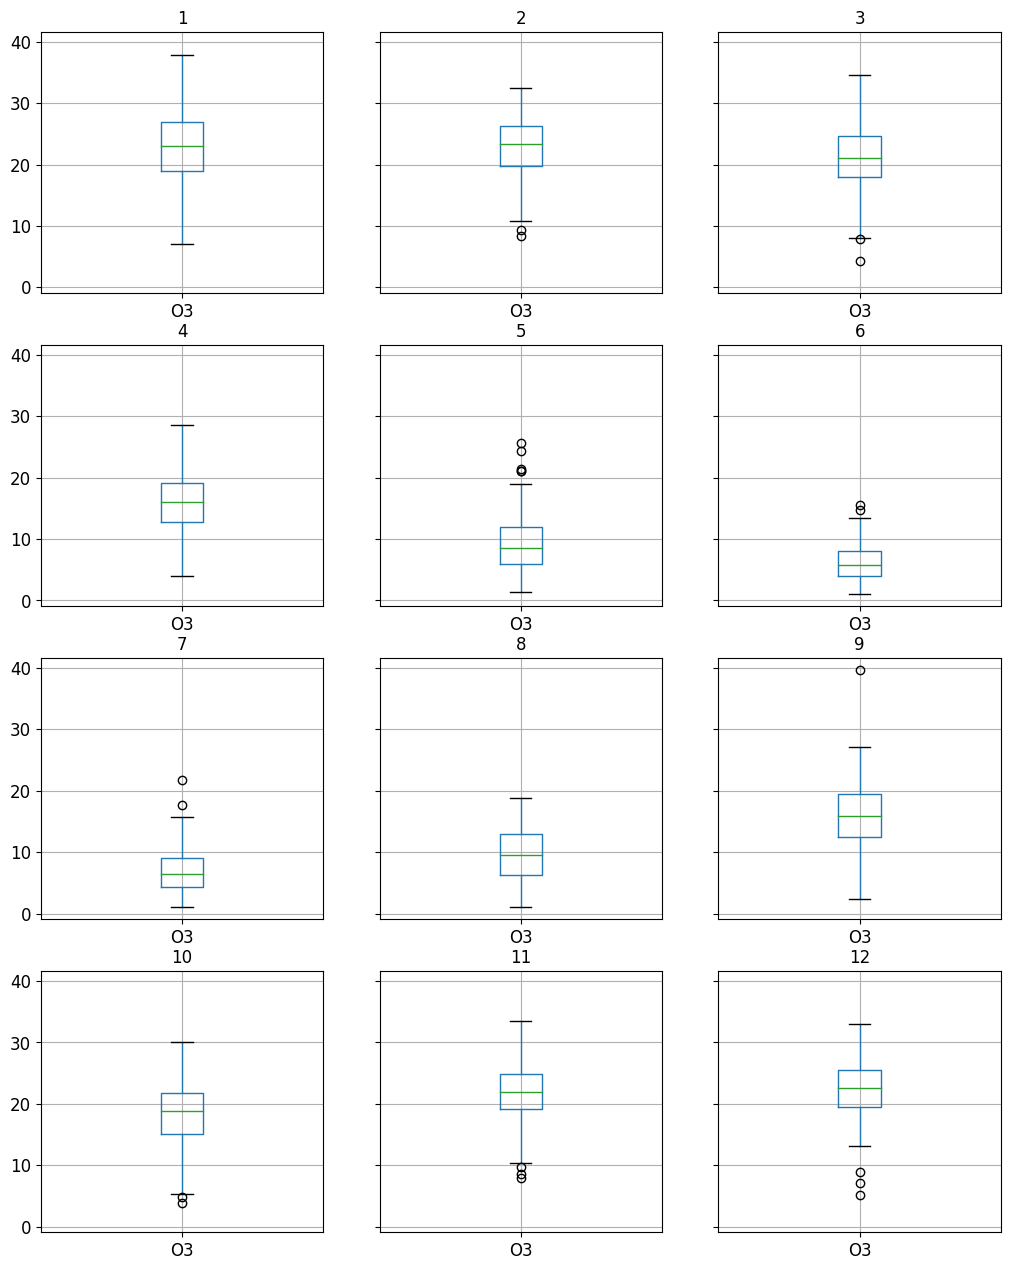

In [219]:
df.groupby('Month').boxplot(column='O3', fontsize=12, figsize=(12, 16))
plt.show()